# Freight Rate Prediction — Solution

**Goal:** predict `posted_rate` for 12,000 loads in `validation.csv` and forecast daily rates for a fixed route (Lexington → Fort Wayne) across December 2025.

**Structure:**
1. Setup & imports
2. Data loading
3. EDA
4. Feature engineering
5. Temporal split
6. Baseline model (Ridge)
7. XGBoost + Optuna hyperparameter search
8. Final model & evaluation
9. Predictions — validation.csv (12K rows)
10. Predictions — december-chart-inputs.csv (31 rows)
11. Scorer validation

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import subprocess
import sys
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import optuna
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

Path('outputs').mkdir(exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Data Loading

In [2]:
train_raw = pd.read_csv('train-test.csv', parse_dates=['date'])
val_raw   = pd.read_csv('validation.csv', parse_dates=['date'])
dec_raw   = pd.read_csv('december-chart-inputs.csv', parse_dates=['date'])

print(f'Train:      {train_raw.shape}  |  {train_raw["date"].min().date()} -> {train_raw["date"].max().date()}')
print(f'Validation: {val_raw.shape}  |  {val_raw["date"].min().date()} -> {val_raw["date"].max().date()}')
print(f'December:   {dec_raw.shape}  |  {dec_raw["date"].min().date()} -> {dec_raw["date"].max().date()}')

Train:      (48000, 14)  |  2025-01-01 -> 2025-10-31
Validation: (12000, 13)  |  2025-11-01 -> 2025-12-31
December:   (31, 7)  |  2025-12-01 -> 2025-12-31


In [3]:
train_raw.head(3)

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54


In [4]:
print('Train columns:     ', train_raw.columns.tolist())
print('Validation columns:', val_raw.columns.tolist())
print('December columns:  ', dec_raw.columns.tolist())

Train columns:      ['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']
Validation columns: ['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']
December columns:   ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


## 3. EDA

In [5]:
print('=== Target stats ===')
print(train_raw['posted_rate'].describe().round(2))
print('\n=== Nulls — train ===')
print(train_raw.isnull().sum()[train_raw.isnull().sum() > 0])
print('\n=== Nulls — validation ===')
print(val_raw.isnull().sum()[val_raw.isnull().sum() > 0])

=== Target stats ===
count    48000.00
mean      2373.98
std       1486.49
min         57.22
25%       1251.55
50%       2030.76
75%       3330.75
max      25533.00
Name: posted_rate, dtype: float64

=== Nulls — train ===
weight          300
market_index    374
dtype: int64

=== Nulls — validation ===
weight          165
market_index    249
dtype: int64


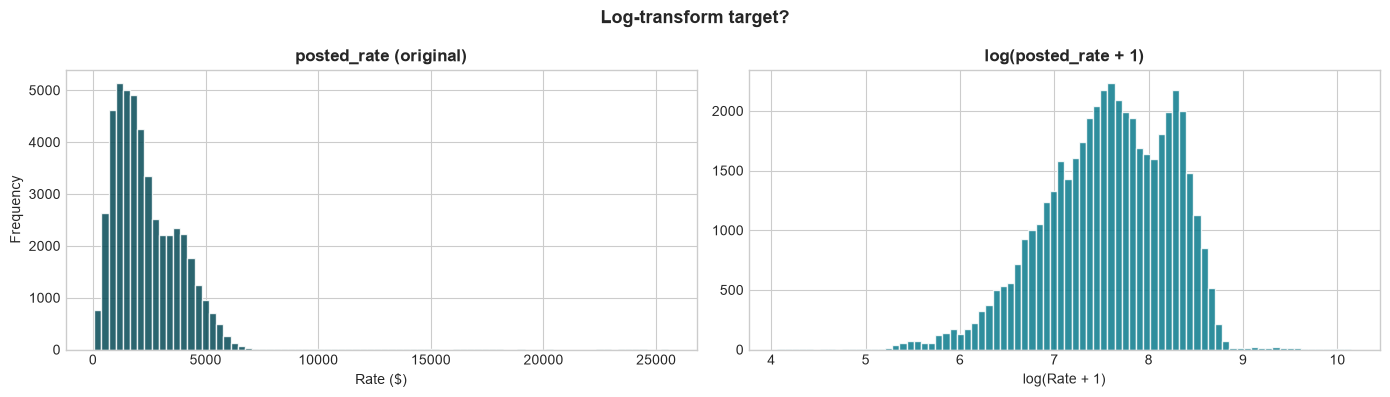

Skewness original: 1.902
Skewness log:      -0.489

Use log target: True


In [6]:
# Check whether a log transform reduces skewness — if so, train on log(target)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_raw['posted_rate'], bins=80, color='#064A56', edgecolor='white', alpha=0.85)
axes[0].set_title('posted_rate (original)', fontweight='bold')
axes[0].set_xlabel('Rate ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(train_raw['posted_rate']), bins=80, color='#0a7a8c', edgecolor='white', alpha=0.85)
axes[1].set_title('log(posted_rate + 1)', fontweight='bold')
axes[1].set_xlabel('log(Rate + 1)')

plt.suptitle('Log-transform target?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

skew_orig = train_raw['posted_rate'].skew()
skew_log  = np.log1p(train_raw['posted_rate']).skew()
print(f'Skewness original: {skew_orig:.3f}')
print(f'Skewness log:      {skew_log:.3f}')

USE_LOG_TARGET = abs(skew_log) < abs(skew_orig)
print(f'\nUse log target: {USE_LOG_TARGET}')

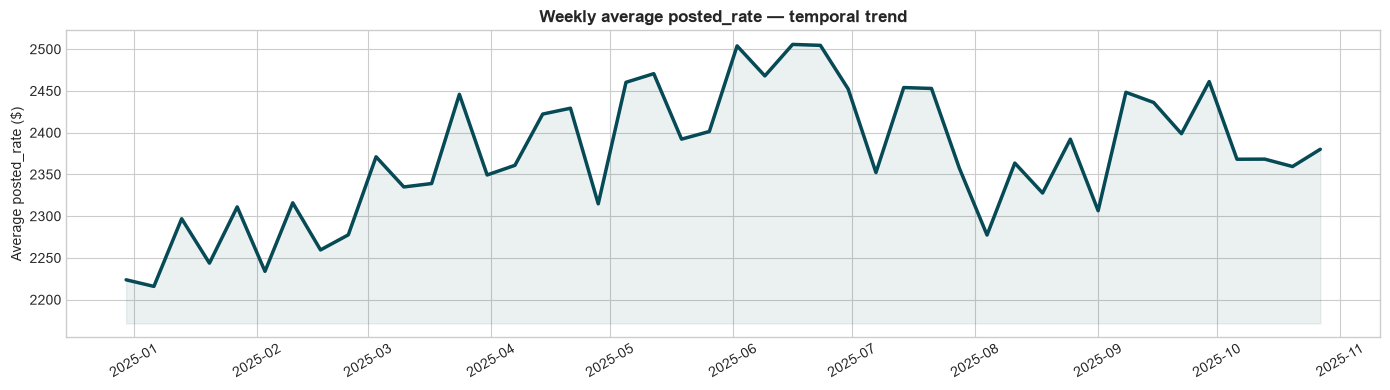

In [7]:
# Weekly average rate — check for temporal drift that justifies a time-based split
weekly = (
    train_raw
    .groupby(train_raw['date'].dt.to_period('W'))['posted_rate']
    .mean()
)
weekly.index = weekly.index.to_timestamp()

plt.figure(figsize=(14, 4))
plt.plot(weekly.index, weekly.values, color='#064A56', linewidth=2.5)
plt.fill_between(weekly.index, weekly.values, weekly.values.min() * 0.98,
                 color='#064A56', alpha=0.08)
plt.title('Weekly average posted_rate — temporal trend', fontweight='bold')
plt.ylabel('Average posted_rate ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('outputs/eda_temporal_trend.png', dpi=150, bbox_inches='tight')
plt.show()

              mean   median      std  count
equipment                                  
Dry Van    2271.55  1953.04  1423.03  27202
Flatbed    2445.09  2076.81  1505.05   8753
Reefer     2553.64  2196.67  1589.67  12045


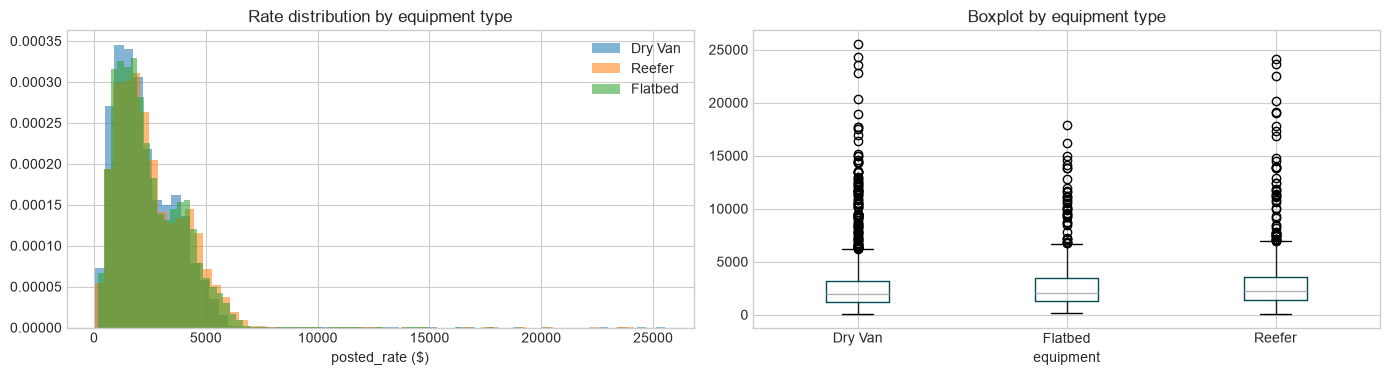

In [8]:
eq_stats = train_raw.groupby('equipment')['posted_rate'].agg(['mean', 'median', 'std', 'count'])
print(eq_stats.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for eq in train_raw['equipment'].unique():
    axes[0].hist(train_raw.loc[train_raw['equipment'] == eq, 'posted_rate'],
                 bins=60, alpha=0.55, label=eq, density=True)
axes[0].set_title('Rate distribution by equipment type')
axes[0].set_xlabel('posted_rate ($)')
axes[0].legend()

train_raw.boxplot(column='posted_rate', by='equipment', ax=axes[1],
                  boxprops=dict(color='#064A56'))
axes[1].set_title('Boxplot by equipment type')
plt.suptitle('')
plt.tight_layout()
plt.savefig('outputs/eda_equipment.png', dpi=150, bbox_inches='tight')
plt.show()

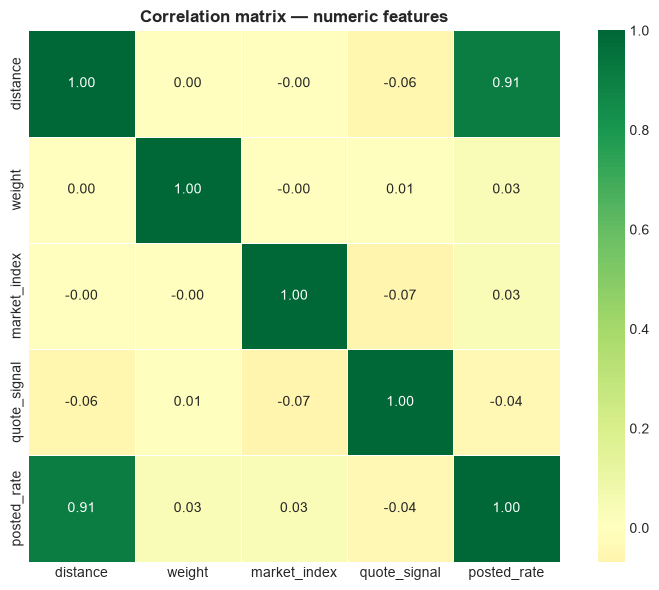

Correlation with posted_rate:
posted_rate     1.000
distance        0.909
weight          0.035
market_index    0.034
quote_signal   -0.040
Name: posted_rate, dtype: float64


In [9]:
numeric_cols = ['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']
corr = train_raw[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation matrix — numeric features', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/eda_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation with posted_rate:')
print(corr['posted_rate'].sort_values(ascending=False).round(3))

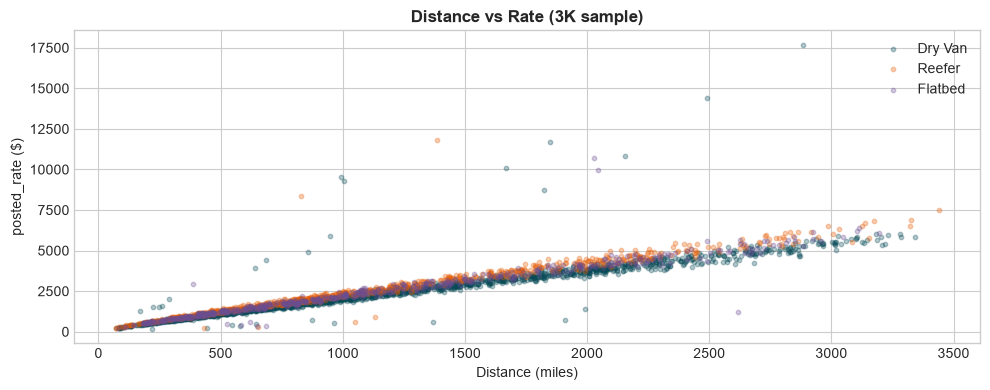

In [10]:
sample = train_raw.sample(3000, random_state=SEED)

plt.figure(figsize=(10, 4))
for eq, color in zip(['Dry Van', 'Reefer', 'Flatbed'], ['#064A56', '#e85d04', '#6a4c93']):
    mask = sample['equipment'] == eq
    plt.scatter(sample.loc[mask, 'distance'], sample.loc[mask, 'posted_rate'],
                alpha=0.3, s=10, color=color, label=eq)
plt.xlabel('Distance (miles)')
plt.ylabel('posted_rate ($)')
plt.title('Distance vs Rate (3K sample)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/eda_distance_vs_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Engineering

Two functions handle all transformations:
- `fit_encoders(train_df)` — computes all encodings from the training set only (no leakage)
- `apply_features(df, encoders)` — applies those encodings to any dataset

In [11]:
def haversine_miles(lat1, lon1, lat2, lon2):
    """Straight-line geographic distance between two points (miles)."""
    R = 3959.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi    = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def fit_encoders(train_df: pd.DataFrame) -> dict:
    """Fit all encoders on the training set only. Returns a dict used by apply_features."""
    encoders = {}
    train_df = train_df.copy()

    # Ordinal equipment encoding
    equipment_list = sorted(train_df['equipment'].unique())
    encoders['equipment_map'] = {eq: i for i, eq in enumerate(equipment_list)}

    # City-level target encoding
    encoders['pickup_means']   = train_df.groupby('pickup')['posted_rate'].mean().to_dict()
    encoders['delivery_means'] = train_df.groupby('delivery')['posted_rate'].mean().to_dict()
    encoders['global_mean']    = train_df['posted_rate'].mean()

    # Route-pair target encoding
    train_df['route'] = train_df['pickup'] + ' -> ' + train_df['delivery']
    encoders['route_means'] = train_df.groupby('route')['posted_rate'].mean().to_dict()

    # Route-level rate-per-mile stats (mean, p75, std)
    train_df['rate_per_mile'] = train_df['posted_rate'] / train_df['distance']
    rpm_stats = train_df.groupby('route')['rate_per_mile'].agg(
        ['mean', 'std', lambda x: x.quantile(0.75)]
    )
    rpm_stats.columns = ['mean', 'std', 'p75']

    encoders['route_rpm']      = rpm_stats['mean'].to_dict()
    encoders['route_rpm_std']  = rpm_stats['std'].fillna(0).to_dict()
    encoders['route_rpm_p75']  = rpm_stats['p75'].to_dict()
    encoders['global_rpm']     = train_df['rate_per_mile'].mean()
    encoders['global_rpm_std'] = train_df['rate_per_mile'].std()
    encoders['global_rpm_p75'] = train_df['rate_per_mile'].quantile(0.75)

    # Route frequency (normalized)
    encoders['route_count']     = train_df.groupby('route').size().to_dict()
    encoders['max_route_count'] = max(encoders['route_count'].values())

    # Medians for NaN imputation — computed on train only
    num_cols = ['weight', 'market_index', 'quote_signal',
                'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance']
    encoders['numeric_medians'] = {
        col: train_df[col].median()
        for col in num_cols if col in train_df.columns
    }

    nan_report = {col: int(train_df[col].isna().sum())
                  for col in num_cols
                  if col in train_df.columns and train_df[col].isna().any()}
    if nan_report:
        for col, n in nan_report.items():
            print(f'  {col}: {n} NaN -> imputed with {encoders["numeric_medians"][col]:.4f}')

    return encoders


def apply_features(df: pd.DataFrame, encoders: dict) -> pd.DataFrame:
    """Transform a dataframe using pre-fitted encoders. Works for train, hold-out, val, and december."""
    d = df.copy()

    # Impute NaN with training medians
    for col, median_val in encoders.get('numeric_medians', {}).items():
        if col in d.columns and d[col].isna().any():
            d[col] = d[col].fillna(median_val)

    # Date features
    d['day_of_week']  = d['date'].dt.dayofweek
    d['month']        = d['date'].dt.month
    d['week_of_year'] = d['date'].dt.isocalendar().week.astype(int)
    d['day_of_year']  = d['date'].dt.dayofyear
    d['is_weekend']   = (d['date'].dt.dayofweek >= 5).astype(int)
    d['quarter']      = d['date'].dt.quarter

    # Equipment encoding
    d['equipment_enc'] = d['equipment'].map(encoders['equipment_map']).fillna(-1).astype(int)

    # City-level target encoding
    gm = encoders['global_mean']
    d['pickup_rate_mean']   = d['pickup'].map(encoders['pickup_means']).fillna(gm)
    d['delivery_rate_mean'] = d['delivery'].map(encoders['delivery_means']).fillna(gm)

    # Route-pair encoding
    d['route'] = d['pickup'] + ' -> ' + d['delivery']
    d['route_rate_mean'] = d['route'].map(encoders['route_means']).fillna(gm)

    # Route rate-per-mile stats
    d['route_rpm']     = d['route'].map(encoders['route_rpm']).fillna(encoders['global_rpm'])
    d['route_rpm_p75'] = d['route'].map(encoders['route_rpm_p75']).fillna(encoders['global_rpm_p75'])
    d['route_rpm_std'] = d['route'].map(encoders['route_rpm_std']).fillna(encoders['global_rpm_std'])
    d['route_count_norm'] = d['route'].map(encoders['route_count']).fillna(0) / encoders['max_route_count']

    # Market signal interaction
    if 'market_index' in d.columns and 'quote_signal' in d.columns:
        d['market_x_quote'] = d['market_index'] * d['quote_signal']

    # Distance features
    d['distance_sq']     = d['distance'] ** 2
    d['distance_x_equip'] = d['distance'] * d['equipment_enc']
    d['haversine_dist']  = haversine_miles(
        d['pickup_lat'], d['pickup_lon'], d['delivery_lat'], d['delivery_lon']
    )
    # Route sinuosity: ratio of road distance to straight-line distance
    d['route_sinuosity'] = d['distance'] / (d['haversine_dist'] + 1e-6)

    # Geographic region grid (3x3 lat/lon buckets)
    d['lat_region'] = pd.cut(d['pickup_lat'], bins=[-90, 35, 42, 90], labels=[0, 1, 2]).astype(int)
    d['lon_region'] = pd.cut(d['pickup_lon'], bins=[-180, -100, -85, 0], labels=[0, 1, 2]).astype(int)
    d['geo_region'] = d['lat_region'] * 3 + d['lon_region']

    feature_cols = [
        'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon',
        'distance', 'distance_sq', 'haversine_dist', 'route_sinuosity',
        'weight', 'equipment_enc', 'distance_x_equip',
        'market_index', 'quote_signal', 'market_x_quote',
        'day_of_week', 'month', 'week_of_year', 'day_of_year', 'is_weekend', 'quarter',
        'pickup_rate_mean', 'delivery_rate_mean',
        'route_rate_mean', 'route_rpm', 'route_rpm_p75', 'route_rpm_std', 'route_count_norm',
        'geo_region', 'lat_region', 'lon_region',
    ]

    available = [c for c in feature_cols if c in d.columns]
    result = d[available]

    remaining_nan = result.isna().sum().sum()
    if remaining_nan > 0:
        print(f'WARNING: {remaining_nan} NaN remaining in {result.columns[result.isna().any()].tolist()}')

    return result

## 5. Temporal Split

A random split would leak future information into training (e.g., using October data to predict August). Instead, the last full month of the training set is reserved as a local hold-out that mimics the temporal gap between train and validation.

In [12]:
month_counts = train_raw.groupby(train_raw['date'].dt.to_period('M')).size()
print('Rows per month in train:')
print(month_counts)

Rows per month in train:
date
2025-01    4918
2025-02    4337
2025-03    5036
2025-04    4819
2025-05    4913
2025-06    4783
2025-07    4912
2025-08    4759
2025-09    4670
2025-10    4853
Freq: M, dtype: int64


In [13]:
# Hold-out = last full month of training data
max_period   = train_raw['date'].dt.to_period('M').max()
holdout_mask = train_raw['date'].dt.to_period('M') == max_period
df_train = train_raw[~holdout_mask].copy().reset_index(drop=True)
df_hold  = train_raw[ holdout_mask].copy().reset_index(drop=True)

print(f'Train:    {df_train.shape[0]:,} rows  ({df_train["date"].min().date()} -> {df_train["date"].max().date()})')
print(f'Hold-out: {df_hold.shape[0]:,} rows  ({df_hold["date"].min().date()} -> {df_hold["date"].max().date()})')

Train:    43,147 rows  (2025-01-01 -> 2025-09-30)
Hold-out: 4,853 rows  (2025-10-01 -> 2025-10-31)


In [14]:
# Fit encoders on training data only, then apply to all sets
encoders = fit_encoders(df_train)

X_train = apply_features(df_train, encoders)
X_hold  = apply_features(df_hold,  encoders)
X_val   = apply_features(val_raw,  encoders)

if USE_LOG_TARGET:
    y_train = np.log1p(df_train['posted_rate'].values)
    y_hold  = np.log1p(df_hold['posted_rate'].values)
    print('Target: log(posted_rate + 1)')
else:
    y_train = df_train['posted_rate'].values
    y_hold  = df_hold['posted_rate'].values
    print('Target: posted_rate (raw)')

print(f'\nX_train: {X_train.shape} | X_hold: {X_hold.shape} | X_val: {X_val.shape}')

  weight: 268 NaN -> imputed with 31435.0000
  market_index: 332 NaN -> imputed with 1.0832
Target: log(posted_rate + 1)

X_train: (43147, 30) | X_hold: (4853, 30) | X_val: (12000, 30)


## 6. Baseline — Ridge Regression

A simple linear model provides a performance floor. If the final model doesn't beat this, something is wrong.

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_hold_scaled  = scaler.transform(X_hold)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_baseline = ridge.predict(X_hold_scaled)

if USE_LOG_TARGET:
    y_pred_baseline_orig = np.expm1(y_pred_baseline)
    y_hold_orig = np.expm1(y_hold)
else:
    y_pred_baseline_orig = y_pred_baseline
    y_hold_orig = y_hold

y_pred_baseline_orig = np.maximum(y_pred_baseline_orig, 1.0)

rmse_baseline = np.sqrt(mean_squared_error(y_hold_orig, y_pred_baseline_orig))
mae_baseline  = mean_absolute_error(y_hold_orig, y_pred_baseline_orig)

print(f'=== Baseline (Ridge) — hold-out ===')
print(f'RMSE: ${rmse_baseline:,.2f}')
print(f'MAE:  ${mae_baseline:,.2f}')
print(f'MAPE: {np.mean(np.abs((y_hold_orig - y_pred_baseline_orig) / y_hold_orig)) * 100:.2f}%')

=== Baseline (Ridge) — hold-out ===
RMSE: $733.04
MAE:  $220.96
MAPE: 10.49%


## 7. XGBoost + Optuna

Optuna runs Bayesian optimization (TPE sampler) over the XGBoost hyperparameter space, minimizing hold-out RMSE across 75 trials.

In [16]:
def objective(trial: optuna.Trial) -> float:
    """
    Optuna objective: propose hyperparameters, train XGBoost, return hold-out RMSE.

    Using log(target) + squared error loss. Combining log transform with Huber loss
    causes numerical instability (expm1 overflow), so squared error is used here —
    the log transform already provides robustness to outliers.
    """
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'objective':    'reg:squarederror',
        'random_state': SEED,
        'n_jobs': -1,
        'tree_method': 'hist',
        'verbosity': 0,
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_hold, y_hold)], verbose=False)

    y_pred = model.predict(X_hold)

    if USE_LOG_TARGET:
        y_pred = np.clip(y_pred, -10, 15)
        y_pred = np.expm1(y_pred)
        y_real = np.expm1(y_hold)
    else:
        y_real = y_hold

    y_pred = np.maximum(y_pred, 1.0)
    return np.sqrt(mean_squared_error(y_real, y_pred))

In [17]:
N_TRIALS = 75

study = optuna.create_study(
    direction='minimize',
    study_name='freight_rate_xgb',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nBest RMSE: ${study.best_value:,.2f}')
print(f'Improvement over baseline: ${rmse_baseline - study.best_value:,.2f}')

  0%|          | 0/75 [00:00<?, ?it/s]


Best RMSE: $657.78
Improvement over baseline: $75.26


In [18]:
best_params = study.best_params
print('=== Best hyperparameters ===')
for k, v in best_params.items():
    print(f'  {k}: {v}')

=== Best hyperparameters ===
  n_estimators: 459
  max_depth: 5
  learning_rate: 0.016739707401719164
  subsample: 0.9518891803512264
  colsample_bytree: 0.4281268065584454
  colsample_bylevel: 0.5291180542935544
  min_child_weight: 18
  reg_alpha: 2.394153504988462
  reg_lambda: 1.7226175784198853e-06


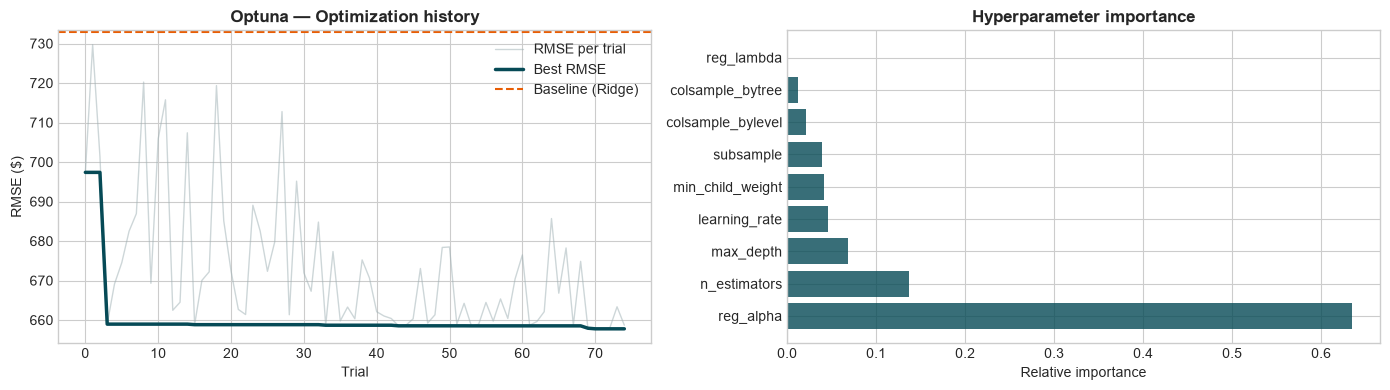

In [19]:
trial_values = [t.value for t in study.trials if t.value is not None]
best_so_far  = [min(trial_values[:i+1]) for i in range(len(trial_values))]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(trial_values, alpha=0.5, color='#9DAFB3', linewidth=1, label='RMSE per trial')
axes[0].plot(best_so_far, color='#064A56', linewidth=2.5, label='Best RMSE')
axes[0].axhline(rmse_baseline, color='#e85d04', linestyle='--', linewidth=1.5, label='Baseline (Ridge)')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('RMSE ($)')
axes[0].set_title('Optuna — Optimization history', fontweight='bold')
axes[0].legend()

try:
    importances = optuna.importance.get_param_importances(study)
    params_sorted = sorted(importances.items(), key=lambda x: x[1], reverse=True)
    names, values = zip(*params_sorted)
    axes[1].barh(names, values, color='#064A56', alpha=0.8)
    axes[1].set_title('Hyperparameter importance', fontweight='bold')
    axes[1].set_xlabel('Relative importance')
except Exception:
    axes[1].text(0.5, 0.5, 'Not available', ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('outputs/optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Final Model

Retrain on the full dataset (train + hold-out) using the best hyperparameters found by Optuna.

In [20]:
# Retrain on full dataset (train + hold-out) with best hyperparameters
X_full = pd.concat([X_train, X_hold], ignore_index=True)
y_full = np.concatenate([y_train, y_hold])

print(f'Training final model on {X_full.shape[0]:,} rows...')

final_params = {**best_params, 'random_state': SEED, 'n_jobs': -1,
                'tree_method': 'hist', 'verbosity': 0}

final_model = xgb.XGBRegressor(**final_params)
final_model.fit(X_full, y_full)
print('Done.')

Training final model on 48,000 rows...
Done.


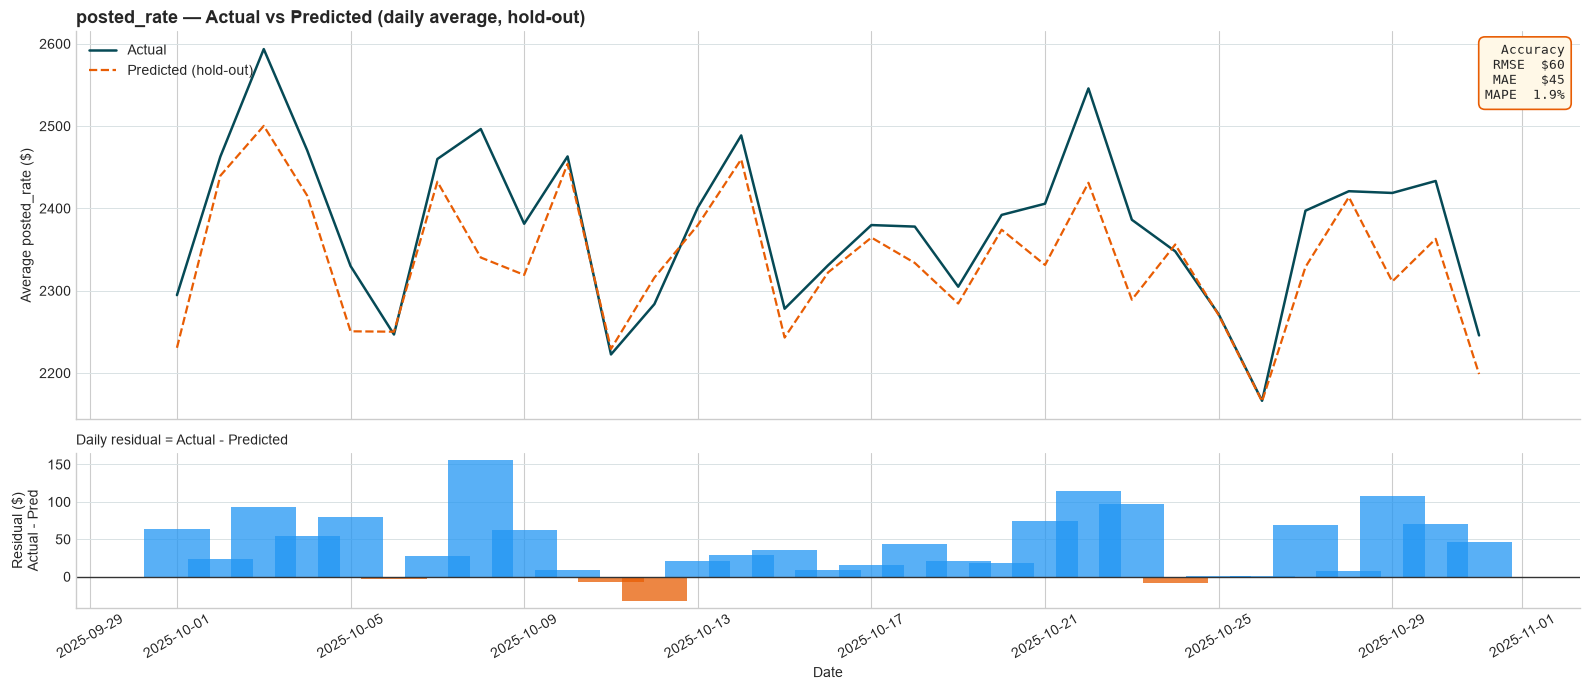

In [21]:
# Daily aggregated Actual vs Predicted — must run AFTER final model training cell
_preds = final_model.predict(X_hold)
if USE_LOG_TARGET:
    _preds  = np.clip(_preds, -10, 15)
    _preds  = np.expm1(_preds)
    _y_hold = np.expm1(y_hold)
else:
    _y_hold = y_hold
_preds = np.maximum(_preds, 1.0)

_df = df_hold[['date']].copy()
_df['real']      = _y_hold
_df['predicted'] = _preds

daily = _df.groupby('date').agg(
    real      = ('real',      'mean'),
    predicted = ('predicted', 'mean'),
).reset_index().sort_values('date')

daily['residual'] = daily['real'] - daily['predicted']

rmse_daily = np.sqrt(((daily['real'] - daily['predicted'])**2).mean())
mae_daily  = (daily['real'] - daily['predicted']).abs().mean()
mape_daily = ((daily['real'] - daily['predicted']).abs() / daily['real']).mean() * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7),
                                gridspec_kw={'height_ratios': [2.5, 1]}, sharex=True)

ax1.plot(daily['date'], daily['real'],      color='#064A56', linewidth=1.8, label='Actual',           zorder=3)
ax1.plot(daily['date'], daily['predicted'], color='#e85d04', linewidth=1.6, linestyle='--',
         label='Predicted (hold-out)', zorder=3)
ax1.set_title('posted_rate — Actual vs Predicted (daily average, hold-out)',
              fontsize=13, fontweight='bold', loc='left')
ax1.set_ylabel('Average posted_rate ($)')
ax1.legend(loc='upper left', framealpha=0.9)
ax1.grid(axis='y', color='#D9E2E4', linewidth=0.7)
ax1.spines[['top', 'right']].set_visible(False)

# Build metrics text separately to avoid f-string backslash issues
metrics_text = (
    "Accuracy\n"
    f"RMSE  ${rmse_daily:,.0f}\n"
    f"MAE   ${mae_daily:,.0f}\n"
    f"MAPE  {mape_daily:.1f}%"
)
ax1.text(0.99, 0.97, metrics_text,
         transform=ax1.transAxes, fontsize=9, va='top', ha='right', family='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF8E7', edgecolor='#e85d04', linewidth=1.2))

colors_res = ['#2196F3' if r >= 0 else '#e85d04' for r in daily['residual']]
ax2.bar(daily['date'], daily['residual'], color=colors_res, alpha=0.75, width=1.5)
ax2.axhline(0, color='#333333', linewidth=1.0)
ax2.set_ylabel('Residual ($)\nActual - Pred')
ax2.set_xlabel('Date')
ax2.set_title('Daily residual = Actual - Predicted', fontsize=10, loc='left')
ax2.grid(axis='y', color='#D9E2E4', linewidth=0.7)
ax2.spines[['top', 'right']].set_visible(False)

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('outputs/actual_vs_predicted_series.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
y_pred_hold_final = final_model.predict(X_hold)

if USE_LOG_TARGET:
    y_pred_hold_final = np.clip(y_pred_hold_final, -10, 15)
    y_pred_hold_final = np.expm1(y_pred_hold_final)
    y_hold_orig       = np.expm1(y_hold)
else:
    y_hold_orig = y_hold

y_pred_hold_final = np.maximum(y_pred_hold_final, 1.0)

rmse_final = np.sqrt(mean_squared_error(y_hold_orig, y_pred_hold_final))
mae_final  = mean_absolute_error(y_hold_orig, y_pred_hold_final)

print(f'           Baseline (Ridge)  ->  XGBoost + Optuna')
print(f'RMSE:      ${rmse_baseline:>10,.2f}  ->  ${rmse_final:,.2f}')
print(f'MAE:       ${mae_baseline:>10,.2f}  ->  ${mae_final:,.2f}')
print(f'Improvement: {((rmse_baseline - rmse_final) / rmse_baseline * 100):.1f}%')

           Baseline (Ridge)  ->  XGBoost + Optuna
RMSE:      $    733.04  ->  $645.14
MAE:       $    220.96  ->  $119.88
Improvement: 12.0%


In [23]:
median_ae = np.median(np.abs(y_pred_hold_final - y_hold_orig))
mape      = np.mean(np.abs((y_hold_orig - y_pred_hold_final) / y_hold_orig)) * 100
wmape     = np.sum(np.abs(y_pred_hold_final - y_hold_orig)) / np.sum(y_hold_orig) * 100
r2        = r2_score(y_hold_orig, y_pred_hold_final)

metrics = {
    'Metric':  ['RMSE ($)', 'MAE ($)', 'Median AE ($)', 'MAPE (%)', 'WMAPE (%)', 'R²'],
    'What it measures': [
        'Error — penalizes large mistakes quadratically',
        'Average absolute error per load',
        'Typical error (outlier-robust)',
        'Average relative error',
        'Weighted relative error (industry standard)',
        'Variance explained by the model'
    ],
    'Baseline (Ridge)': [
        f'${rmse_baseline:,.0f}',
        f'${mae_baseline:,.0f}',
        f'${np.median(np.abs(y_pred_baseline_orig - y_hold_orig)):,.0f}',
        f'{np.mean(np.abs((y_hold_orig - y_pred_baseline_orig) / y_hold_orig)) * 100:.1f}%',
        f'{np.sum(np.abs(y_pred_baseline_orig - y_hold_orig)) / np.sum(y_hold_orig) * 100:.1f}%',
        f'{r2_score(y_hold_orig, y_pred_baseline_orig):.4f}'
    ],
    'XGBoost + Optuna': [
        f'${rmse_final:,.0f}', f'${mae_final:,.0f}', f'${median_ae:,.0f}',
        f'{mape:.1f}%', f'{wmape:.1f}%', f'{r2:.4f}'
    ]
}

df_metrics = pd.DataFrame(metrics)
print('=' * 82)
print('                  HOLD-OUT METRICS (October 2025)')
print('=' * 82)
print(df_metrics.to_string(index=False))
print('=' * 82)
print(f'\nNote: high RMSE vs MAE/MedianAE is driven by {(np.abs(y_pred_hold_final - y_hold_orig) > 1000).sum()} outlier loads')
print(f'that account for 1.3% of predictions but ~98% of total squared error.')

                  HOLD-OUT METRICS (October 2025)
       Metric                               What it measures Baseline (Ridge) XGBoost + Optuna
     RMSE ($) Error — penalizes large mistakes quadratically             $733             $645
      MAE ($)                Average absolute error per load             $221             $120
Median AE ($)                 Typical error (outlier-robust)              $93              $38
     MAPE (%)                         Average relative error            10.5%             5.6%
    WMAPE (%)    Weighted relative error (industry standard)             9.3%             5.0%
           R²                Variance explained by the model           0.7700           0.8219

Note: high RMSE vs MAE/MedianAE is driven by 63 outlier loads
that account for 1.3% of predictions but ~98% of total squared error.


In [24]:
# Outlier analysis — understand the RMSE / MAE gap
df_diag = df_hold.copy()
df_diag['predicted'] = y_pred_hold_final
df_diag['real']      = y_hold_orig
df_diag['error_abs'] = np.abs(y_pred_hold_final - y_hold_orig)
df_diag['error_pct'] = (df_diag['error_abs'] / df_diag['real']) * 100

print('=== Absolute error distribution ===')
print(df_diag['error_abs'].describe().round(2))

n_1k = (df_diag['error_abs'] > 1000).sum()
n_2k = (df_diag['error_abs'] > 2000).sum()
n_5k = (df_diag['error_abs'] > 5000).sum()
print(f'\nPredictions with error > $1,000: {n_1k}')
print(f'Predictions with error > $2,000: {n_2k}')
print(f'Predictions with error > $5,000: {n_5k}')

total_se   = (df_diag['error_abs'] ** 2).sum()
outlier_se = (df_diag.loc[df_diag['error_abs'] > 1000, 'error_abs'] ** 2).sum()
print(f'\nErrors > $1,000 account for {outlier_se / total_se * 100:.1f}% of total squared error')

=== Absolute error distribution ===
count     4853.00
mean       119.88
std        633.97
min          0.01
25%         16.68
50%         38.17
75%         80.94
max      13732.89
Name: error_abs, dtype: float64

Predictions with error > $1,000: 63
Predictions with error > $2,000: 47
Predictions with error > $5,000: 20

Errors > $1,000 account for 97.6% of total squared error


In [25]:
cols_show = ['pickup', 'delivery', 'distance', 'equipment', 'real', 'predicted', 'error_abs', 'error_pct']
print('=== Top 20 worst predictions ===')
print(df_diag.nlargest(20, 'error_abs')[cols_show].round(2).to_string(index=False))

print('\n=== Mean absolute error by distance bucket ===')
df_diag['dist_bucket'] = pd.cut(df_diag['distance'],
                                 bins=[0, 500, 1000, 1500, 2000, 9999],
                                 labels=['0-500mi', '500-1K', '1K-1.5K', '1.5K-2K', '2K+'])
print(df_diag.groupby('dist_bucket', observed=True)['error_abs'].agg(['mean', 'median', 'count']).round(2))

=== Top 20 worst predictions ===
        pickup      delivery  distance equipment     real   predicted  error_abs  error_pct
     Milwaukee   Bakersfield    1893.0   Dry Van 17514.11 3781.219971   13732.89      78.41
      Columbia        Tucson    2023.4   Flatbed 17893.17 4346.560059   13546.61      75.71
        Boston   Bakersfield    2979.1    Reefer 19110.30 6252.859863   12857.44      67.28
        Toledo   Albuquerque    1684.3    Reefer 14784.38 3437.649902   11346.73      76.75
   Bakersfield      Columbia    2251.9   Dry Van 14403.14 4412.509766    9990.63      69.36
        Albany   Albuquerque    2492.6   Dry Van 14425.42 4470.640137    9954.78      69.01
   Los Angeles      Richmond    2782.4   Dry Van 15003.55 5079.439941    9924.11      66.15
       Atlanta       Phoenix    2083.1    Reefer 13894.55 4510.759766    9383.79      67.54
     Lexington       Lubbock    1187.0   Dry Van 11696.44 2425.439941    9271.00      79.26
Corpus Christi     Las Vegas    1383.3   Flatbe

=== Mean absolute error by equipment type ===
             mean  median       max  count
equipment                                 
Dry Van    114.17   35.26  13732.89   2745
Flatbed    115.15   39.69  13546.61    918
Reefer     136.72   43.34  12857.44   1190

New routes in hold-out: 8 of 4853
MAE — known routes: $119.28
MAE — new routes:   $487.57


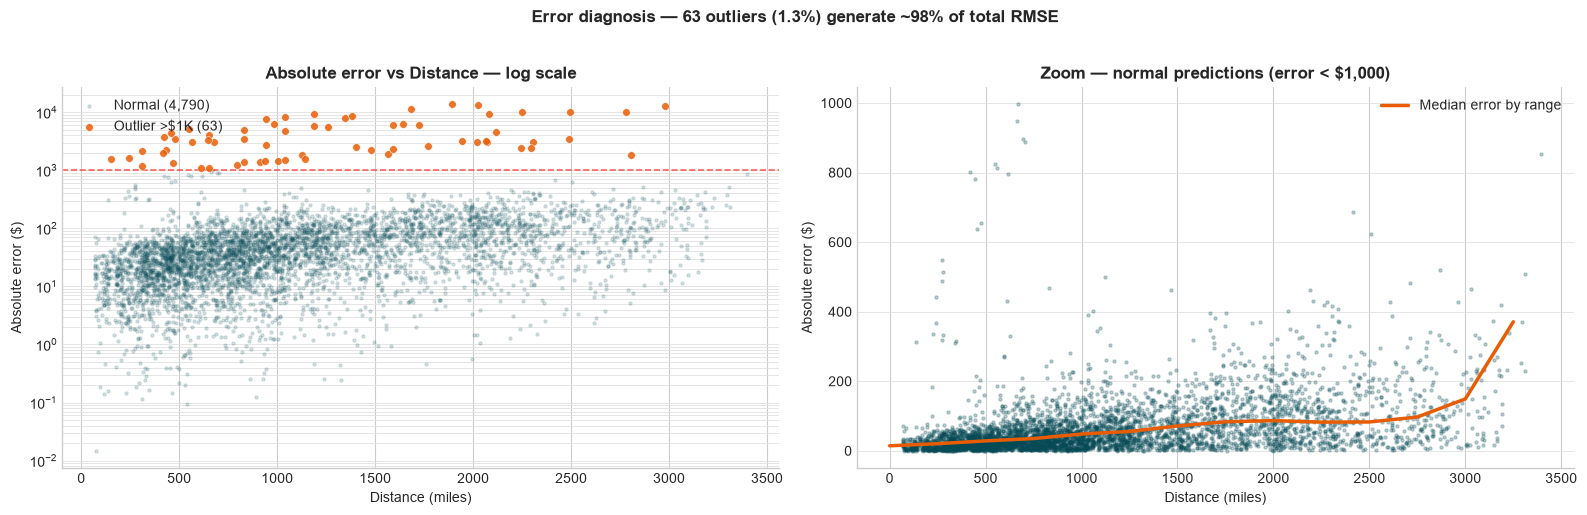

In [26]:
print('=== Mean absolute error by equipment type ===')
print(df_diag.groupby('equipment')['error_abs'].agg(['mean', 'median', 'max', 'count']).round(2))

# Check if errors concentrate on routes the model never saw during training
routes_in_train = set(df_train['pickup'] + ' -> ' + df_train['delivery'])
df_diag['route']     = df_diag['pickup'] + ' -> ' + df_diag['delivery']
df_diag['new_route'] = ~df_diag['route'].isin(routes_in_train)

print(f'\nNew routes in hold-out: {df_diag["new_route"].sum()} of {len(df_diag)}')
print(f'MAE — known routes: ${df_diag.loc[~df_diag["new_route"], "error_abs"].mean():,.2f}')
print(f'MAE — new routes:   ${df_diag.loc[ df_diag["new_route"], "error_abs"].mean():,.2f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

mask_outlier = df_diag['error_abs'] > 1000
normal   = df_diag[~mask_outlier]
outliers = df_diag[ mask_outlier]

axes[0].scatter(normal['distance'],   normal['error_abs'],   alpha=0.15, s=5,
                color='#064A56', label=f'Normal ({len(normal):,})')
axes[0].scatter(outliers['distance'], outliers['error_abs'], alpha=0.85, s=30, zorder=5,
                color='#e85d04', edgecolors='white', linewidths=0.4,
                label=f'Outlier >$1K ({len(outliers)})')
axes[0].axhline(1000, color='red', linestyle='--', linewidth=1.2, alpha=0.6)
axes[0].set_yscale('log')
axes[0].set_title('Absolute error vs Distance — log scale', fontweight='bold')
axes[0].set_xlabel('Distance (miles)')
axes[0].set_ylabel('Absolute error ($)')
axes[0].legend(loc='upper left')
axes[0].grid(axis='y', which='both', color='#E0E0E0', linewidth=0.6)
axes[0].spines[['top', 'right']].set_visible(False)

normal_copy = normal.copy()
normal_copy['dist_bin'] = (normal_copy['distance'] // 250) * 250
avg_by_dist = normal_copy.groupby('dist_bin')['error_abs'].median().reset_index()
axes[1].scatter(normal['distance'], normal['error_abs'], alpha=0.25, s=5, color='#064A56')
axes[1].plot(avg_by_dist['dist_bin'], avg_by_dist['error_abs'],
             color='#e85d04', linewidth=2.5, label='Median error by range', zorder=5)
axes[1].set_title('Zoom — normal predictions (error < $1,000)', fontweight='bold')
axes[1].set_xlabel('Distance (miles)')
axes[1].set_ylabel('Absolute error ($)')
axes[1].legend()
axes[1].grid(axis='y', color='#E0E0E0', linewidth=0.6)
axes[1].spines[['top', 'right']].set_visible(False)

fig.suptitle(
    f'Error diagnosis — {len(outliers)} outliers ({len(outliers)/len(df_diag)*100:.1f}%) '
    f'generate ~98% of total RMSE',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('outputs/error_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()

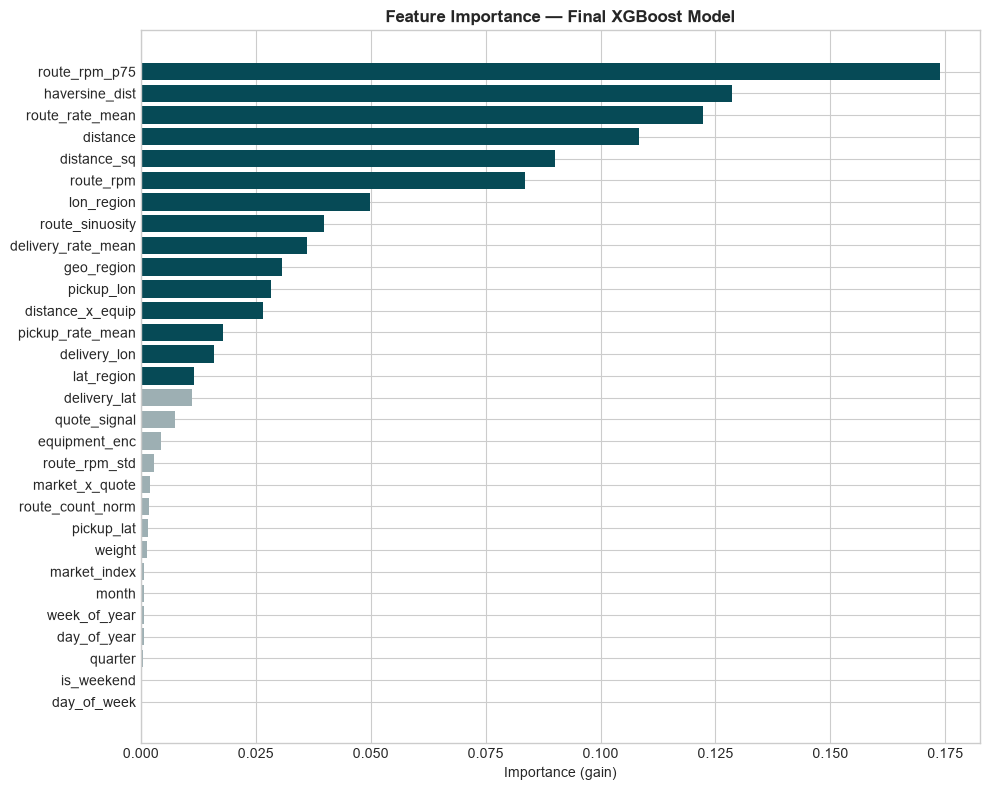

Top 5 features:
        feature  importance
  route_rpm_p75    0.173846
 haversine_dist    0.128651
route_rate_mean    0.122197
       distance    0.108311
    distance_sq    0.090140


In [27]:
importance_df = pd.DataFrame({
    'feature':    X_full.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#064A56' if imp > importance_df['importance'].median() else '#9DAFB3'
          for imp in importance_df['importance']]
plt.barh(importance_df['feature'], importance_df['importance'], color=colors)
plt.title('Feature Importance — Final XGBoost Model', fontweight='bold')
plt.xlabel('Importance (gain)')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(importance_df.sort_values('importance', ascending=False).head(5).to_string(index=False))

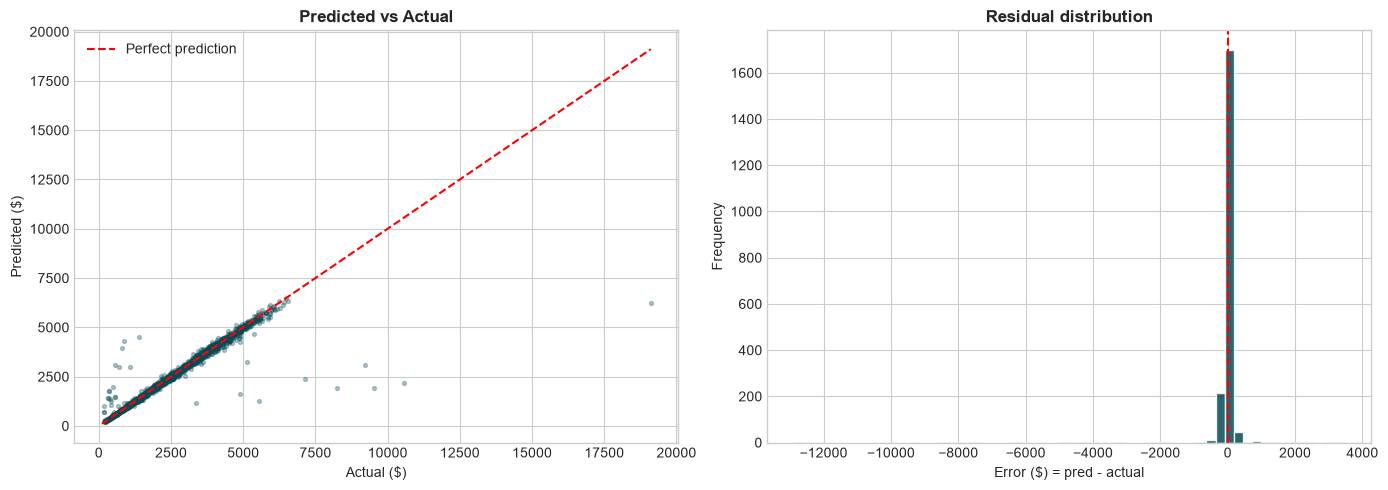

Mean error (bias): $-22.33
Error std:         $503.32


In [28]:
sample_idx = np.random.choice(len(y_hold_orig), size=min(2000, len(y_hold_orig)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_hold_orig[sample_idx], y_pred_hold_final[sample_idx],
                alpha=0.3, s=8, color='#064A56')
lims = [min(y_hold_orig.min(), y_pred_hold_final.min()),
        max(y_hold_orig.max(), y_pred_hold_final.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual ($)')
axes[0].set_ylabel('Predicted ($)')
axes[0].set_title('Predicted vs Actual', fontweight='bold')
axes[0].legend()

errors = y_pred_hold_final[sample_idx] - y_hold_orig[sample_idx]
axes[1].hist(errors, bins=60, color='#064A56', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Error ($) = pred - actual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/prediction_quality.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean error (bias): ${errors.mean():,.2f}')
print(f'Error std:         ${errors.std():,.2f}')

## 9. Predictions — validation.csv (12,000 rows)

In [29]:
y_val_pred = final_model.predict(X_val)

if USE_LOG_TARGET:
    y_val_pred = np.expm1(y_val_pred)

y_val_pred = np.maximum(y_val_pred, 1.0)

print(f'Predictions generated: {len(y_val_pred):,}')
print(f'Min: ${y_val_pred.min():,.2f} | Max: ${y_val_pred.max():,.2f} | Mean: ${y_val_pred.mean():,.2f}')
print(f'Any non-positive: {(y_val_pred <= 0).any()}')

Predictions generated: 12,000
Min: $219.02 | Max: $6,519.29 | Mean: $2,327.64
Any non-positive: False


In [30]:
predictions_df = pd.DataFrame({
    'load_id':        val_raw['load_id'],
    'predicted_rate': y_val_pred
})

assert len(predictions_df) == 12_000
assert (predictions_df['predicted_rate'] > 0).all()
assert not predictions_df['load_id'].duplicated().any()

output_path = 'outputs/validation_predictions.csv'
predictions_df.to_csv(output_path, index=False)
print(f'Saved: {output_path}')
print(predictions_df.head(5).to_string(index=False))

Saved: outputs/validation_predictions.csv
  load_id  predicted_rate
TE-000001      862.330811
TE-000002     5081.957031
TE-000003     5229.751465
TE-000004     4116.819824
TE-000005     1840.140991


## 10. Predictions — December Chart (31 rows)

The december file is missing `market_index`, `quote_signal`, and lat/lon coordinates. Strategy:
- Coordinates: looked up from training data (Lexington pickup rows, Fort Wayne delivery rows)
- `market_index` / `quote_signal`: forecasted with Exponential Smoothing (seasonal_periods=7)   to preserve the weekly cycle visible in the historical series

In [31]:
# Look up Lexington and Fort Wayne coordinates from training data
lex_rows = train_raw[train_raw['pickup']   == 'Lexington'][['pickup_lat',   'pickup_lon']].drop_duplicates()
fw_rows  = train_raw[train_raw['delivery'] == 'Fort Wayne'][['delivery_lat', 'delivery_lon']].drop_duplicates()

lex_lat = lex_rows['pickup_lat'].mean()
lex_lon = lex_rows['pickup_lon'].mean()
fw_lat  = fw_rows['delivery_lat'].mean()
fw_lon  = fw_rows['delivery_lon'].mean()

print(f'Lexington:  ({lex_lat:.5f}, {lex_lon:.5f})')
print(f'Fort Wayne: ({fw_lat:.5f}, {fw_lon:.5f})')

Lexington:  (36.99152, -84.99876)
Fort Wayne: (41.31561, -85.36206)


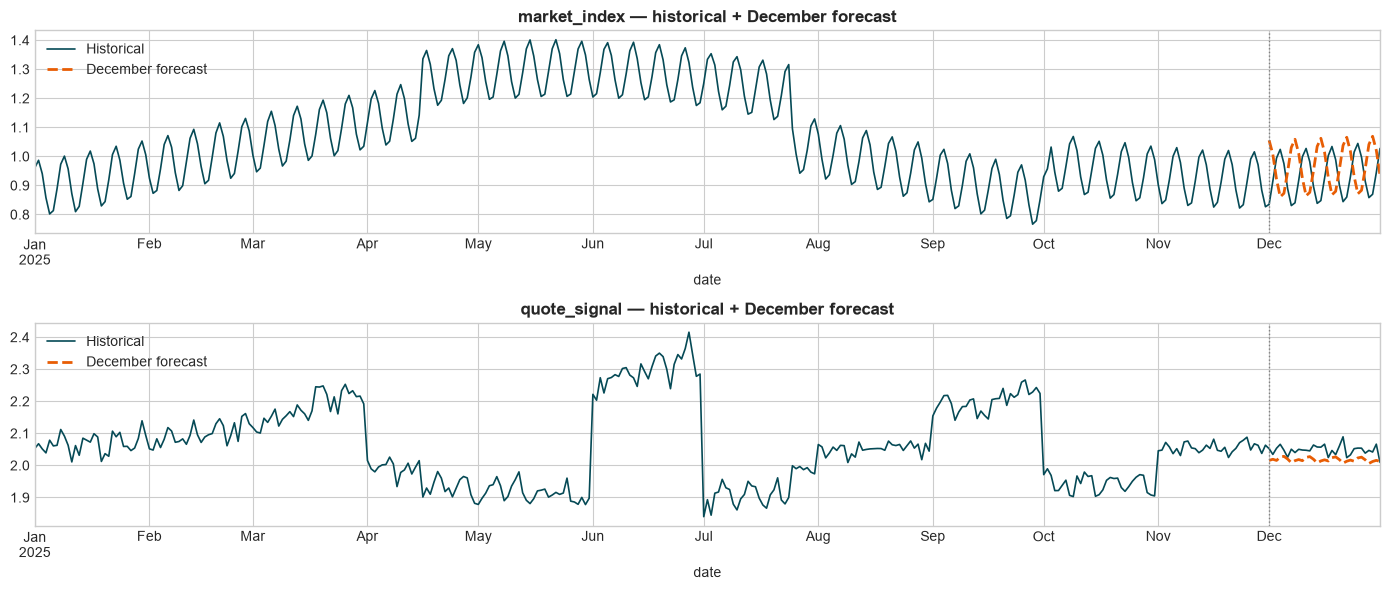

In [32]:
# Forecast market_index and quote_signal for December using Exponential Smoothing
# Using seasonal_periods=7 to capture the weekly cycle visible in the historical series
all_data     = pd.concat([train_raw, val_raw]).sort_values('date')
daily_market = all_data.groupby('date')['market_index'].mean()
daily_quote  = all_data.groupby('date')['quote_signal'].mean()

def forecast_index(series: pd.Series, periods: int = 31) -> np.ndarray:
    model = ExponentialSmoothing(
        series, trend='add', seasonal='add', seasonal_periods=7
    ).fit(optimized=True)
    return model.forecast(periods).values

market_forecast = forecast_index(daily_market)
quote_forecast  = forecast_index(daily_quote)

dec_dates = pd.date_range('2025-12-01', periods=31, freq='D')

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
daily_market.plot(ax=axes[0], color='#064A56', linewidth=1.2, label='Historical')
pd.Series(market_forecast, index=dec_dates).plot(ax=axes[0], color='#e85d04',
           linewidth=2, linestyle='--', label='December forecast')
axes[0].axvline(pd.Timestamp('2025-12-01'), color='gray', linestyle=':', linewidth=1)
axes[0].set_title('market_index — historical + December forecast', fontweight='bold')
axes[0].legend()

daily_quote.plot(ax=axes[1], color='#064A56', linewidth=1.2, label='Historical')
pd.Series(quote_forecast, index=dec_dates).plot(ax=axes[1], color='#e85d04',
           linewidth=2, linestyle='--', label='December forecast')
axes[1].axvline(pd.Timestamp('2025-12-01'), color='gray', linestyle=':', linewidth=1)
axes[1].set_title('quote_signal — historical + December forecast', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/december_index_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
dec_extended = dec_raw.copy()

# Add coordinates looked up from training data
dec_extended['pickup_lat']   = lex_lat
dec_extended['pickup_lon']   = lex_lon
dec_extended['delivery_lat'] = fw_lat
dec_extended['delivery_lon'] = fw_lon

# Assign day-specific forecasted index values (preserves weekly seasonality)
dec_extended = dec_extended.sort_values('date').reset_index(drop=True)
dec_extended['market_index'] = market_forecast
dec_extended['quote_signal'] = quote_forecast

In [34]:
X_dec = apply_features(dec_extended, encoders)

y_dec_pred = final_model.predict(X_dec)

if USE_LOG_TARGET:
    y_dec_pred = np.expm1(y_dec_pred)

y_dec_pred = np.maximum(y_dec_pred, 1.0)

print('December rate predictions:')
for date, rate in zip(dec_raw['date'].dt.date, y_dec_pred):
    print(f'  {date}: ${rate:,.2f}')

December rate predictions:
  2025-12-01: $847.30
  2025-12-02: $847.12
  2025-12-03: $845.24
  2025-12-04: $844.98
  2025-12-05: $844.55
  2025-12-06: $845.91
  2025-12-07: $846.96
  2025-12-08: $847.30
  2025-12-09: $847.27
  2025-12-10: $845.24
  2025-12-11: $844.98
  2025-12-12: $844.55
  2025-12-13: $845.91
  2025-12-14: $847.04
  2025-12-15: $847.30
  2025-12-16: $847.27
  2025-12-17: $846.39
  2025-12-18: $844.98
  2025-12-19: $844.55
  2025-12-20: $845.91
  2025-12-21: $847.20
  2025-12-22: $847.30
  2025-12-23: $847.27
  2025-12-24: $846.39
  2025-12-25: $844.98
  2025-12-26: $844.55
  2025-12-27: $845.91
  2025-12-28: $847.20
  2025-12-29: $835.09
  2025-12-30: $834.52
  2025-12-31: $833.39


In [ ]:
dec_output = dec_raw.copy()
dec_output['predicted_rate'] = y_dec_pred

expected_cols = ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
assert list(dec_output.columns) == expected_cols
assert len(dec_output) == 31
assert (dec_output['predicted_rate'] > 0).all()

dec_output_path = 'outputs/december_chart_inputs.csv'
dec_output.to_csv(dec_output_path, index=False)
print(f'Saved: {dec_output_path}')
print(dec_output[['date', 'predicted_rate']].to_string(index=False))

Saved: outputs/december-chart-inputs.csv
      date  predicted_rate
2025-12-01      847.295410
2025-12-02      847.117004
2025-12-03      845.235352
2025-12-04      844.975098
2025-12-05      844.552490
2025-12-06      845.911499
2025-12-07      846.958496
2025-12-08      847.295410
2025-12-09      847.265076
2025-12-10      845.235352
2025-12-11      844.975098
2025-12-12      844.552490
2025-12-13      845.911499
2025-12-14      847.036560
2025-12-15      847.295410
2025-12-16      847.265076
2025-12-17      846.385376
2025-12-18      844.975098
2025-12-19      844.552490
2025-12-20      845.911499
2025-12-21      847.201172
2025-12-22      847.295410
2025-12-23      847.265076
2025-12-24      846.385376
2025-12-25      844.975098
2025-12-26      844.552490
2025-12-27      845.911499
2025-12-28      847.201172
2025-12-29      835.087341
2025-12-30      834.520996
2025-12-31      833.387085


## 11. Scorer Validation

In [ ]:
python_exe = sys.executable

result = subprocess.run(
    [
        python_exe, 'score.py',
        '--predictions',          'outputs/validation_predictions.csv',
        '--december-predictions', 'outputs/december_chart_inputs.csv',
        '--output-dir',           'outputs/scorer_results'
    ],
    capture_output=True, text=True
)

print(result.stdout)
if result.returncode != 0:
    print('STDERR:')
    print(result.stderr)

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: outputs/scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.



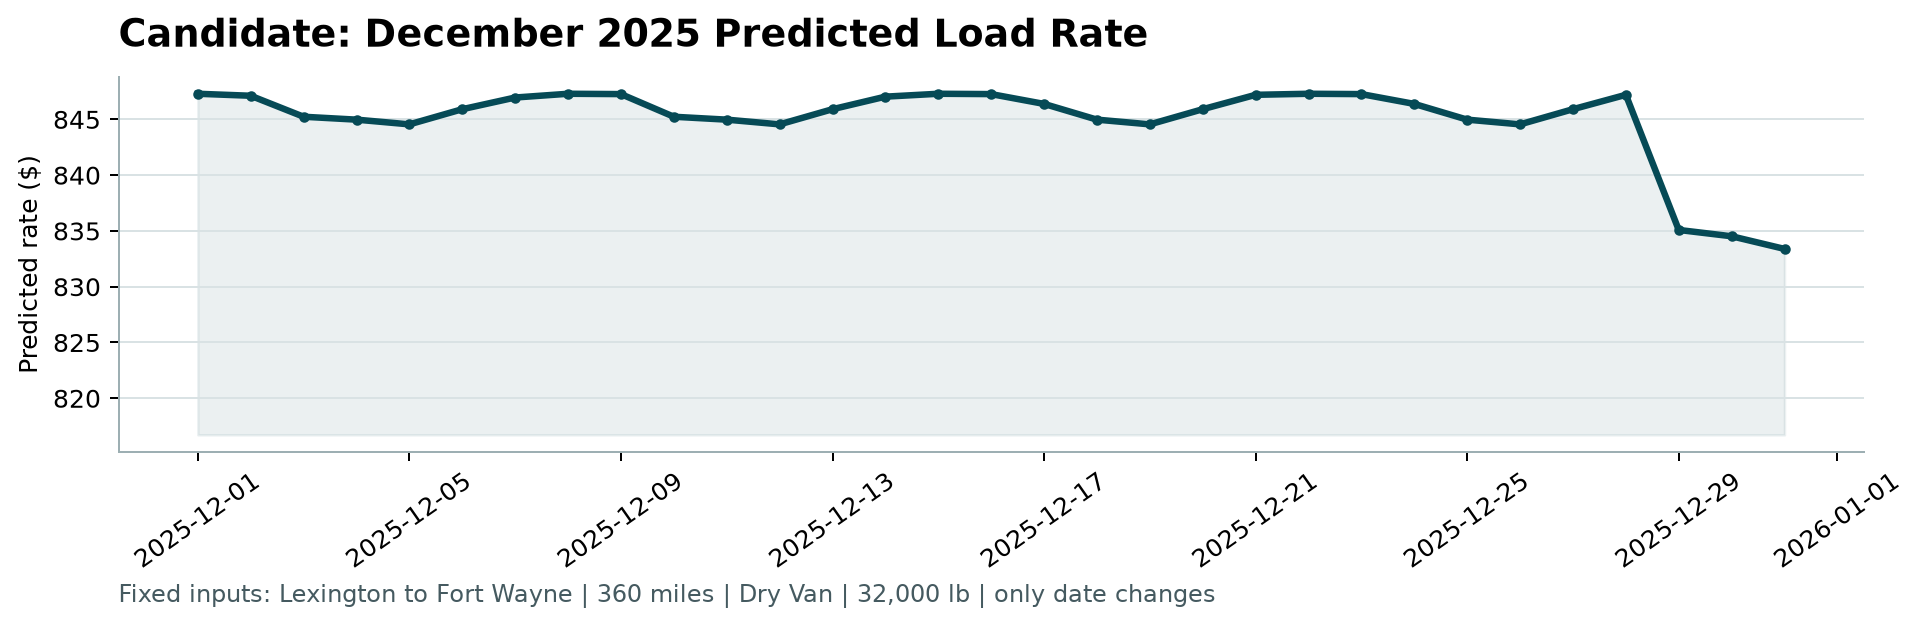

In [37]:
chart_path = 'outputs/scorer_results/candidate_december.png'
if Path(chart_path).exists():
    from IPython.display import Image
    display(Image(filename=chart_path))
else:
    print(f'Chart not found at {chart_path}')

## Summary

**Output files:**
- `outputs/validation_predictions.csv` — 12,000 predictions for submission
- `outputs/december-chart-inputs.csv` — 31 December forecasts
- `outputs/scorer_results/candidate_december.png` — official scorer chart

In [38]:
print('=' * 50)
print('           FINAL MODEL SUMMARY')
print('=' * 50)
print(f'Training rows:     {X_full.shape[0]:,}')
print(f'Features:          {X_full.shape[1]}')
print(f'Optuna trials:     {len(study.trials)}')
print(f'Best RMSE:         ${study.best_value:,.2f}')
print(f'Baseline RMSE:     ${rmse_baseline:,.2f}')
print(f'Improvement:       {((rmse_baseline - study.best_value) / rmse_baseline * 100):.1f}%')
print(f'Outputs:           validation_predictions.csv + december-chart-inputs.csv')
print('=' * 50)

           FINAL MODEL SUMMARY
Training rows:     48,000
Features:          30
Optuna trials:     75
Best RMSE:         $657.78
Baseline RMSE:     $733.04
Improvement:       10.3%
Outputs:           validation_predictions.csv + december-chart-inputs.csv
